# TSE Description Ablation — ChatTS-8B vs Qwen3-VL-8B · 98 Templates

**Experiment:** `tse_desc_ablation_full`  
**Setup:** random picking · k=1 · 3 seeds (0, 3, 6) · 98 TSE templates

| Condition | Model | `use_label_desc` |
|---|---|---|
| **ChatTS · No Desc** | `bytedance-research/ChatTS-8B` | 0 |
| **ChatTS · With Desc** | `bytedance-research/ChatTS-8B` | 1 |
| **QwenVL · No Desc** | `Qwen/Qwen3-VL-8B-Instruct` | 0 |
| **QwenVL · With Desc** | `Qwen/Qwen3-VL-8B-Instruct` | 1 |

**Sections:**
1. Load data from W&B
2. Overall accuracy table (all templates pooled as one task)
3. Full 4-way comparison (table + heatmap + winner counts)
4. Per-model description effect (Δ bar charts, scatter, Wilcoxon test)
5. Results by TSE difficulty and category
6. Critical Difference diagram (Friedman + Wilcoxon + Holm–Bonferroni)

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, networkx
from pathlib import Path
from scipy.stats import wilcoxon, friedmanchisquare, spearmanr
from tqdm.auto import tqdm
import json, os, sys

if wandb.api.api_key is None:
    for folder in ["", "wandb_logger", "logger"]:
        token_path = Path(folder) / "token.txt"
        if token_path.exists():
            wandb.login(key=token_path.read_text().strip())
            break

ENTITY  = "aviramom-"
PROJECT = "ts-icl"
EXP_ID  = "tse_desc_ablation_full"

CHATTS_MODEL = "bytedance-research/ChatTS-8B"
QWENVL_MODEL = "Qwen/Qwen3-VL-8B-Instruct"

COND_CHATTS_NO   = "ChatTS · No Desc"
COND_CHATTS_WITH = "ChatTS · With Desc"
COND_VL_NO       = "QwenVL · No Desc"
COND_VL_WITH     = "QwenVL · With Desc"
CONDITIONS       = [COND_CHATTS_NO, COND_CHATTS_WITH, COND_VL_NO, COND_VL_WITH]

N_SEEDS = 3   # seeds 0, 3, 6

# Path to augmented TSE dataset for metadata (difficulty, category)
TSE_META_PATH = Path("../qa_dataset_augmented.json")
if not TSE_META_PATH.exists():
    TSE_META_PATH = Path("qa_dataset_augmented.json")

api = wandb.Api(timeout=60)
print(f"Connected to {ENTITY}/{PROJECT}")
print(f"  Exp ID : {EXP_ID}")

/home/aviramom/.conda/envs/multits/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Connected to aviramom-/ts-icl
  Exp ID : tse_desc_ablation_full


## 1 · Load Data from W&B

Fetches all runs for `tse_desc_ablation_full` and caches locally.  
Set `FORCE_REFRESH = True` when new runs finish.

In [2]:
CONFIG_KEYS = ["task_id", "method", "num_samples", "exp_id",
               "num_shots", "random_seed", "picking_strategy", "use_label_desc"]
METRIC_KEYS = ["balanced_accuracy", "f1_macro", "f1_weighted",
               "num_of_classes", "total_test_size", "flawed_count", "flawed_percentage"]

CACHE_PATH    = Path("cache_tse_desc_ablation_full.parquet")
FORCE_REFRESH = True   # flip to False after first successful fetch

def get_val(cfg, summary, key):
    return summary.get(key, cfg.get(key))

def fetch_exp(exp_id, cache_path):
    if cache_path.exists() and not FORCE_REFRESH:
        df = pd.read_parquet(cache_path)
        print(f"Loaded {len(df)} rows from cache ({cache_path})")
        return df
    all_runs = list(api.runs(path=f"{ENTITY}/{PROJECT}", per_page=1000))
    rows = []
    for run in tqdm(all_runs, desc=f"Processing {exp_id}"):
        summary = {k: v for k, v in (run.summary or {}).items() if not k.startswith("_")}
        cfg     = run.config or {}
        if get_val(cfg, summary, "exp_id") != exp_id:
            continue
        row = {"run_id": run.id, "run_name": run.name, "state": run.state}
        for k in CONFIG_KEYS:
            row[k] = get_val(cfg, summary, k)
        for k in METRIC_KEYS:
            row[k] = get_val(cfg, summary, k)
        rows.append(row)
    df = pd.DataFrame(rows)
    for col in METRIC_KEYS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df.to_parquet(cache_path)
    print(f"Cached {len(df)} rows → {cache_path}")
    return df

df_raw = fetch_exp(EXP_ID, CACHE_PATH)

def assign_condition(row):
    method = str(row.get("method", ""))
    desc   = int(pd.to_numeric(row.get("use_label_desc", 0), errors="coerce") or 0)
    if CHATTS_MODEL in method:
        return COND_CHATTS_WITH if desc else COND_CHATTS_NO
    elif QWENVL_MODEL in method:
        return COND_VL_WITH if desc else COND_VL_NO
    return "Unknown"

df_raw["condition"] = df_raw.apply(assign_condition, axis=1)
# Extract tid as integer from task_id "icl_tse_<tid>"
df_raw["tid"] = pd.to_numeric(
    df_raw["task_id"].str.replace("icl_tse_", "", regex=False),
    errors="coerce"
).astype("Int64")

print(f"\n{'─'*55}")
print(f"Total runs loaded : {len(df_raw)}")
print(f"Finished          : {(df_raw['state'] == 'finished').sum()}")
print(f"\nCondition counts:")
for cond in CONDITIONS:
    n  = (df_raw["condition"] == cond).sum()
    nf = ((df_raw["condition"] == cond) & (df_raw["state"] == "finished")).sum()
    print(f"  {cond:25s}: {n:4d} total, {nf:4d} finished")

Processing tse_desc_ablation_full:   0%|          | 0/2640 [00:00<?, ?it/s]

Cached 1176 rows → cache_tse_desc_ablation_full.parquet

───────────────────────────────────────────────────────
Total runs loaded : 1176
Finished          : 1128

Condition counts:
  ChatTS · No Desc         :  294 total,  282 finished
  ChatTS · With Desc       :  294 total,  282 finished
  QwenVL · No Desc         :  294 total,  282 finished
  QwenVL · With Desc       :  294 total,  282 finished


In [3]:
finished = df_raw[df_raw["state"] == "finished"].copy()
tids     = sorted(finished["tid"].dropna().unique().tolist())

print(f"Templates present in results : {len(tids)}")
print(f"Total finished runs          : {len(finished)}")
print()

# Coverage check: each tid should have N_SEEDS runs per condition
count_check = finished.pivot_table(
    index="tid", columns="condition",
    values="balanced_accuracy", aggfunc="count"
).fillna(0).astype(int)
incomplete = count_check[(count_check < N_SEEDS).any(axis=1)]
print(f"Templates with < {N_SEEDS} seeds in any condition: {len(incomplete)}")
if len(incomplete) > 0:
    print("Incomplete templates:")
    display(incomplete)

Templates present in results : 94
Total finished runs          : 1128

Templates with < 3 seeds in any condition: 0


In [4]:
# Load TSE metadata: difficulty, category, subcategory, question per tid
if TSE_META_PATH.exists():
    with open(TSE_META_PATH) as f:
        tse_entries = json.load(f)
    # One entry per (tid, variant) — take first entry per tid
    tid_meta = {}
    for e in tse_entries:
        t = e["tid"]
        if t not in tid_meta:
            tid_meta[t] = {
                "difficulty":   e.get("difficulty", "unknown"),
                "category":     e.get("category",   "unknown"),
                "subcategory":  e.get("subcategory", "unknown"),
                "question":     e.get("question",   ""),
            }
    print(f"Loaded metadata for {len(tid_meta)} tids from {TSE_META_PATH}")
else:
    tid_meta = {}
    print("WARNING: qa_dataset_augmented.json not found — metadata columns will be empty")

# Add metadata columns to finished df
finished["difficulty"]  = finished["tid"].map(lambda t: tid_meta.get(t, {}).get("difficulty", "unknown"))
finished["category"]    = finished["tid"].map(lambda t: tid_meta.get(t, {}).get("category",   "unknown"))
finished["subcategory"] = finished["tid"].map(lambda t: tid_meta.get(t, {}).get("subcategory", "unknown"))
finished["question"]    = finished["tid"].map(lambda t: tid_meta.get(t, {}).get("question",   ""))

print("\nDifficulty distribution:")
print(finished.drop_duplicates("tid")["difficulty"].value_counts().to_string())
print("\nCategory distribution:")
print(finished.drop_duplicates("tid")["category"].value_counts().to_string())

Loaded metadata for 98 tids from ../qa_dataset_augmented.json

Difficulty distribution:
difficulty
hard      59
easy      32
medium     3

Category distribution:
category
Pattern Recognition    48
Similarity Analysis    17
Noise Understanding    13
Anolmaly Detection      9
Causality Analysis      7


## 2 · Overall Accuracy — All Templates Pooled as One Task

Two views of benchmark-level accuracy:
- **Macro avg** — unweighted mean of per-template balanced accuracy (treats all templates equally)
- **Weighted avg** — weighted by `total_test_size` (approximates pooled accuracy across all samples)

OVERALL ACCURACY — all 98 TSE templates


,Templates,Macro Avg BalAcc,Macro Std,Weighted Avg BalAcc
Condition,,,,
ChatTS · No Desc,94,0.6562,±0.1840,0.6566
ChatTS · With Desc,94,0.6051,±0.1854,0.6003
QwenVL · No Desc,94,0.7970,±0.1778,0.7874
QwenVL · With Desc,94,0.7981,±0.1851,0.7937


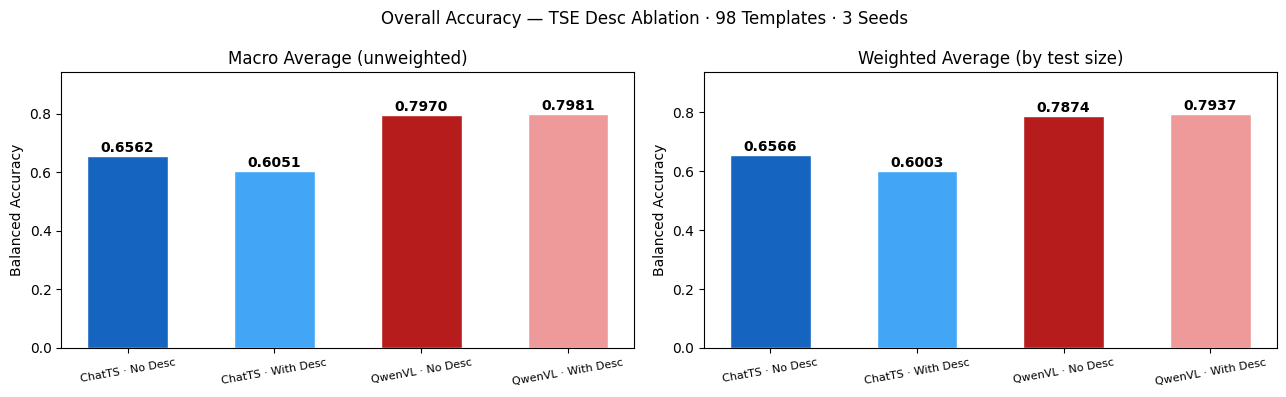

In [5]:
overall_rows = []
for cond in CONDITIONS:
    cdf = finished[finished["condition"] == cond]
    if cdf.empty:
        continue
    # Mean per tid across seeds first, then average over tids
    per_tid = cdf.groupby("tid").agg(
        bal_acc=("balanced_accuracy", "mean"),
        test_size=("total_test_size", "mean"),
    ).dropna(subset=["bal_acc"])

    macro = per_tid["bal_acc"].mean()
    macro_std = per_tid["bal_acc"].std()
    weights = per_tid["test_size"].fillna(1)
    weighted = np.average(per_tid["bal_acc"], weights=weights)

    overall_rows.append({
        "Condition":           cond,
        "Templates":           len(per_tid),
        "Macro Avg BalAcc":    macro,
        "Macro Std":           macro_std,
        "Weighted Avg BalAcc": weighted,
    })

overall_df = pd.DataFrame(overall_rows).set_index("Condition")

print("OVERALL ACCURACY — all 98 TSE templates")
display(
    overall_df.style
    .format({
        "Templates":           "{:.0f}",
        "Macro Avg BalAcc":    "{:.4f}",
        "Macro Std":           "±{:.4f}",
        "Weighted Avg BalAcc": "{:.4f}",
    })
    .background_gradient(cmap="RdYlGn", axis=0,
                         subset=["Macro Avg BalAcc", "Weighted Avg BalAcc"], vmin=0, vmax=1)
    .set_caption("Overall benchmark accuracy — 4 conditions · 98 TSE templates · 3 seeds")
)

# Bar chart
color_map = {
    COND_CHATTS_NO:   "#1565C0",
    COND_CHATTS_WITH: "#42A5F5",
    COND_VL_NO:       "#B71C1C",
    COND_VL_WITH:     "#EF9A9A",
}
conds_present = [c for c in CONDITIONS if c in overall_df.index]
bar_colors    = [color_map.get(c, "gray") for c in conds_present]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, title in zip(
    axes,
    ["Macro Avg BalAcc", "Weighted Avg BalAcc"],
    ["Macro Average (unweighted)", "Weighted Average (by test size)"],
):
    vals = overall_df.loc[conds_present, metric].values
    bars = ax.bar(conds_present, vals, color=bar_colors, width=0.55, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.18)
    ax.set_ylabel("Balanced Accuracy")
    ax.set_title(title)
    ax.tick_params(axis="x", labelsize=8, rotation=10)

plt.suptitle("Overall Accuracy — TSE Desc Ablation · 98 Templates · 3 Seeds", fontsize=12)
plt.tight_layout()
plt.show()

## 3 · Full 4-Way Comparison per Template

Balanced accuracy (macro recall) — mean ± std across 3 seeds (0, 3, 6).

In [6]:
mean_p = finished.pivot_table(
    index="tid", columns="condition",
    values="balanced_accuracy", aggfunc="mean"
)
std_p = finished.pivot_table(
    index="tid", columns="condition",
    values="balanced_accuracy", aggfunc="std"
)

cols   = [c for c in CONDITIONS if c in mean_p.columns]
mean_p = mean_p[cols].reindex(tids)
std_p  = std_p[cols].reindex(tids)
mean_p.columns.name = std_p.columns.name = ""

DELTA_CHATTS = "Δ ChatTS (with−no)"
DELTA_VL     = "Δ QwenVL (with−no)"
DELTA_COLS   = []
if COND_CHATTS_NO in mean_p.columns and COND_CHATTS_WITH in mean_p.columns:
    mean_p[DELTA_CHATTS] = mean_p[COND_CHATTS_WITH] - mean_p[COND_CHATTS_NO]
    DELTA_COLS.append(DELTA_CHATTS)
if COND_VL_NO in mean_p.columns and COND_VL_WITH in mean_p.columns:
    mean_p[DELTA_VL] = mean_p[COND_VL_WITH] - mean_p[COND_VL_NO]
    DELTA_COLS.append(DELTA_VL)

# Add metadata to per-tid table
mean_p["Difficulty"] = pd.Series({t: tid_meta.get(t, {}).get("difficulty", "?") for t in mean_p.index})
mean_p["Category"]   = pd.Series({t: tid_meta.get(t, {}).get("category",   "?") for t in mean_p.index})
mean_p["Question"]   = pd.Series({t: tid_meta.get(t, {}).get("question",   "")[:55] for t in mean_p.index})

macro = mean_p[cols + DELTA_COLS].mean(); macro.name = "Macro Avg"
mean_p = pd.concat([mean_p, macro.to_frame().T])
mean_p.index.name = "tid"

print(f"Conditions : {cols}")
print(f"Delta cols : {DELTA_COLS}")
print()

# Formatted table
display_cols = cols + DELTA_COLS + ["Difficulty", "Category", "Question"]
fmt = mean_p[display_cols].copy().astype(object)
for col in mean_p.columns:
    if col in display_cols and col not in DELTA_COLS + ["Difficulty", "Category", "Question"]:
        for idx in mean_p.index:
            m_val = mean_p.loc[idx, col]
            if idx != "Macro Avg" and col in std_p.columns and idx in std_p.index:
                s_val = std_p.loc[idx, col]
                fmt.loc[idx, col] = f"{m_val:.3f} ± {s_val:.3f}" if pd.notna(m_val) else "—"
            else:
                fmt.loc[idx, col] = f"{m_val:.3f}" if pd.notna(m_val) else "—"
    elif col in DELTA_COLS:
        for idx in mean_p.index:
            v = mean_p.loc[idx, col]
            fmt.loc[idx, col] = f"{v:+.3f}" if pd.notna(v) else "—"

print("BALANCED ACCURACY  (mean ± std over 3 seeds) — per TSE template")
display(
    fmt.style
    .set_caption("Balanced Accuracy — ChatTS-8B vs Qwen3-VL-8B · No Desc vs With Desc · per TSE template")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
)

Conditions : ['ChatTS · No Desc', 'ChatTS · With Desc', 'QwenVL · No Desc', 'QwenVL · With Desc']
Delta cols : ['Δ ChatTS (with−no)', 'Δ QwenVL (with−no)']

BALANCED ACCURACY  (mean ± std over 3 seeds) — per TSE template


,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc,Δ ChatTS (with−no),Δ QwenVL (with−no),Difficulty,Category,Question
tid,,,,,,,,,
1,0.741 ± 0.257,0.778 ± 0.192,0.630 ± 0.339,0.778 ± 0.192,+0.037,+0.148,easy,Pattern Recognition,What is the type of the trend of the given time series?
2,0.444 ± 0.111,0.593 ± 0.064,0.963 ± 0.064,1.000 ± 0.000,+0.148,+0.037,hard,Pattern Recognition,What is the most likely linear trend coefficient of the
3,0.944 ± 0.096,1.000 ± 0.000,0.833 ± 0.167,0.889 ± 0.192,+0.056,+0.056,easy,Pattern Recognition,Does the given time series exhibit any monotonic increa
4,0.778 ± 0.192,0.704 ± 0.064,0.889 ± 0.111,1.000 ± 0.000,-0.074,+0.111,easy,Pattern Recognition,What is the direction of the linear trend of the given
5,0.778 ± 0.111,0.407 ± 0.128,0.815 ± 0.064,0.741 ± 0.064,-0.370,-0.074,hard,Pattern Recognition,Given that following time series exhibit piecewise line
6,0.556 ± 0.096,0.556 ± 0.096,0.500 ± 0.167,0.611 ± 0.096,+0.000,+0.111,easy,Pattern Recognition,How does the linear trend in the first half of the time
7,0.500 ± 0.000,0.667 ± 0.000,0.667 ± 0.167,0.611 ± 0.192,+0.167,-0.056,hard,Pattern Recognition,"The given time series has an increasing trend, is it a"
8,0.500 ± 0.000,0.556 ± 0.096,0.500 ± 0.000,0.778 ± 0.255,+0.056,+0.278,hard,Pattern Recognition,"The given time series has a decreasing trend, is it a l"
9,0.750 ± 0.083,0.583 ± 0.083,0.778 ± 0.127,0.778 ± 0.048,-0.167,+0.000,hard,Pattern Recognition,The given time series has multiple trends followed by e


### Balanced Accuracy Heatmap — All 4 Conditions

In [7]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

display(
    tbl[cols].style
    .background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1)
    .format("{:.3f}", na_rep="—")
    .set_caption("Balanced Accuracy — all 4 conditions")
)

vabs = tbl[DELTA_COLS].abs().max().max()
display(
    tbl[DELTA_COLS].style
    .background_gradient(cmap="RdBu", axis=None, vmin=-vabs, vmax=vabs)
    .format("{:+.3f}", na_rep="—")
    .set_caption("Δ per model  (With Desc − No Desc)")
)

,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc
tid,,,,
1,0.741,0.778,0.630,0.778
2,0.444,0.593,0.963,1.000
3,0.944,1.000,0.833,0.889
4,0.778,0.704,0.889,1.000
5,0.778,0.407,0.815,0.741
6,0.556,0.556,0.500,0.611
7,0.500,0.667,0.667,0.611
8,0.500,0.556,0.500,0.778
9,0.750,0.583,0.778,0.778


,Δ ChatTS (with−no),Δ QwenVL (with−no)
tid,,
1,+0.037,+0.148
2,+0.148,+0.037
3,+0.056,+0.056
4,-0.074,+0.111
5,-0.370,-0.074
6,+0.000,+0.111
7,+0.167,-0.056
8,+0.056,+0.278
9,-0.167,+0.000


### Per-Template Winner and Win Counts

In [8]:
def highlight_winner_row(row):
    styles  = [""] * len(row)
    cond_c  = [c for c in row.index if c not in DELTA_COLS + ["Difficulty", "Category", "Question"]]
    if not cond_c or row[cond_c].isna().all():
        return styles
    best_col = row[cond_c].idxmax()
    for i, col in enumerate(row.index):
        if col == best_col:
            styles[i] = "background-color: #4CAF50; color: white; font-weight: bold"
    return styles

tbl = mean_p.drop(index="Macro Avg", errors="ignore")
display(
    tbl[cols].style
    .apply(highlight_winner_row, axis=1)
    .format("{:.3f}", na_rep="—")
    .set_caption("Winner per template (green) — across all 4 conditions")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
)

winners  = tbl[cols].idxmax(axis=1)
win_cnts = winners.value_counts().reindex(cols, fill_value=0)
total    = len(tbl.dropna(how="all"))
summary  = pd.DataFrame({"Templates Won": win_cnts, "Win %": (win_cnts / total * 100).round(1)})
summary  = summary.sort_values("Templates Won", ascending=False)

print(f"\nWin counts — Balanced Accuracy  (out of {total} templates)")
display(
    summary.style
    .background_gradient(cmap="YlGn", subset=["Templates Won"], axis=0)
    .format({"Templates Won": "{:d}", "Win %": "{:.1f}%"})
    .set_caption("# templates each condition wins")
)

,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc
tid,,,,
1,0.741,0.778,0.630,0.778
2,0.444,0.593,0.963,1.000
3,0.944,1.000,0.833,0.889
4,0.778,0.704,0.889,1.000
5,0.778,0.407,0.815,0.741
6,0.556,0.556,0.500,0.611
7,0.500,0.667,0.667,0.611
8,0.500,0.556,0.500,0.778
9,0.750,0.583,0.778,0.778



Win counts — Balanced Accuracy  (out of 94 templates)


,Templates Won,Win %
QwenVL · No Desc,38,40.4%
QwenVL · With Desc,32,34.0%
ChatTS · No Desc,16,17.0%
ChatTS · With Desc,8,8.5%


### Macro Average Bar Chart

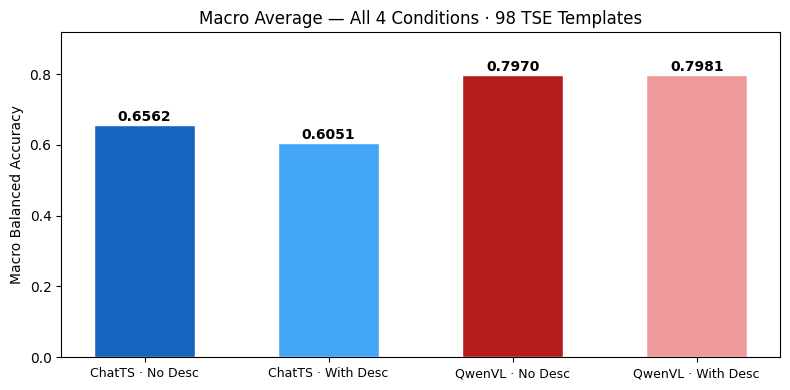

Macro Balanced Accuracy:
  ChatTS · No Desc         : 0.6562
  ChatTS · With Desc       : 0.6051
  QwenVL · No Desc         : 0.7970
  QwenVL · With Desc       : 0.7981


In [9]:
macro_vals = mean_p.loc["Macro Avg", cols]

color_map = {
    COND_CHATTS_NO:   "#1565C0",
    COND_CHATTS_WITH: "#42A5F5",
    COND_VL_NO:       "#B71C1C",
    COND_VL_WITH:     "#EF9A9A",
}
bar_colors = [color_map.get(c, "gray") for c in cols]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cols, macro_vals.values, color=bar_colors, width=0.55, edgecolor="white")
for bar, val in zip(bars, macro_vals.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(macro_vals.values) * 1.15)
ax.set_ylabel("Macro Balanced Accuracy")
ax.set_title("Macro Average — All 4 Conditions · 98 TSE Templates")
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.show()

print("Macro Balanced Accuracy:")
for c in cols:
    print(f"  {c:25s}: {macro_vals[c]:.4f}")

## 4 · Per-Model Description Effect

For each model separately: Δ = With Description − No Description.  
Green bars = description helps; red bars = description hurts.

ChatTS-8B:
  Mean Δ              : -0.0511
  Templates improved  : 30 / 94  (31.9%)
  Templates hurt      : 51 / 94  (54.3%)
  Templates tied      : 13 / 94

Qwen3-VL-8B:
  Mean Δ              : +0.0011
  Templates improved  : 39 / 94  (41.5%)
  Templates hurt      : 36 / 94  (38.3%)
  Templates tied      : 19 / 94



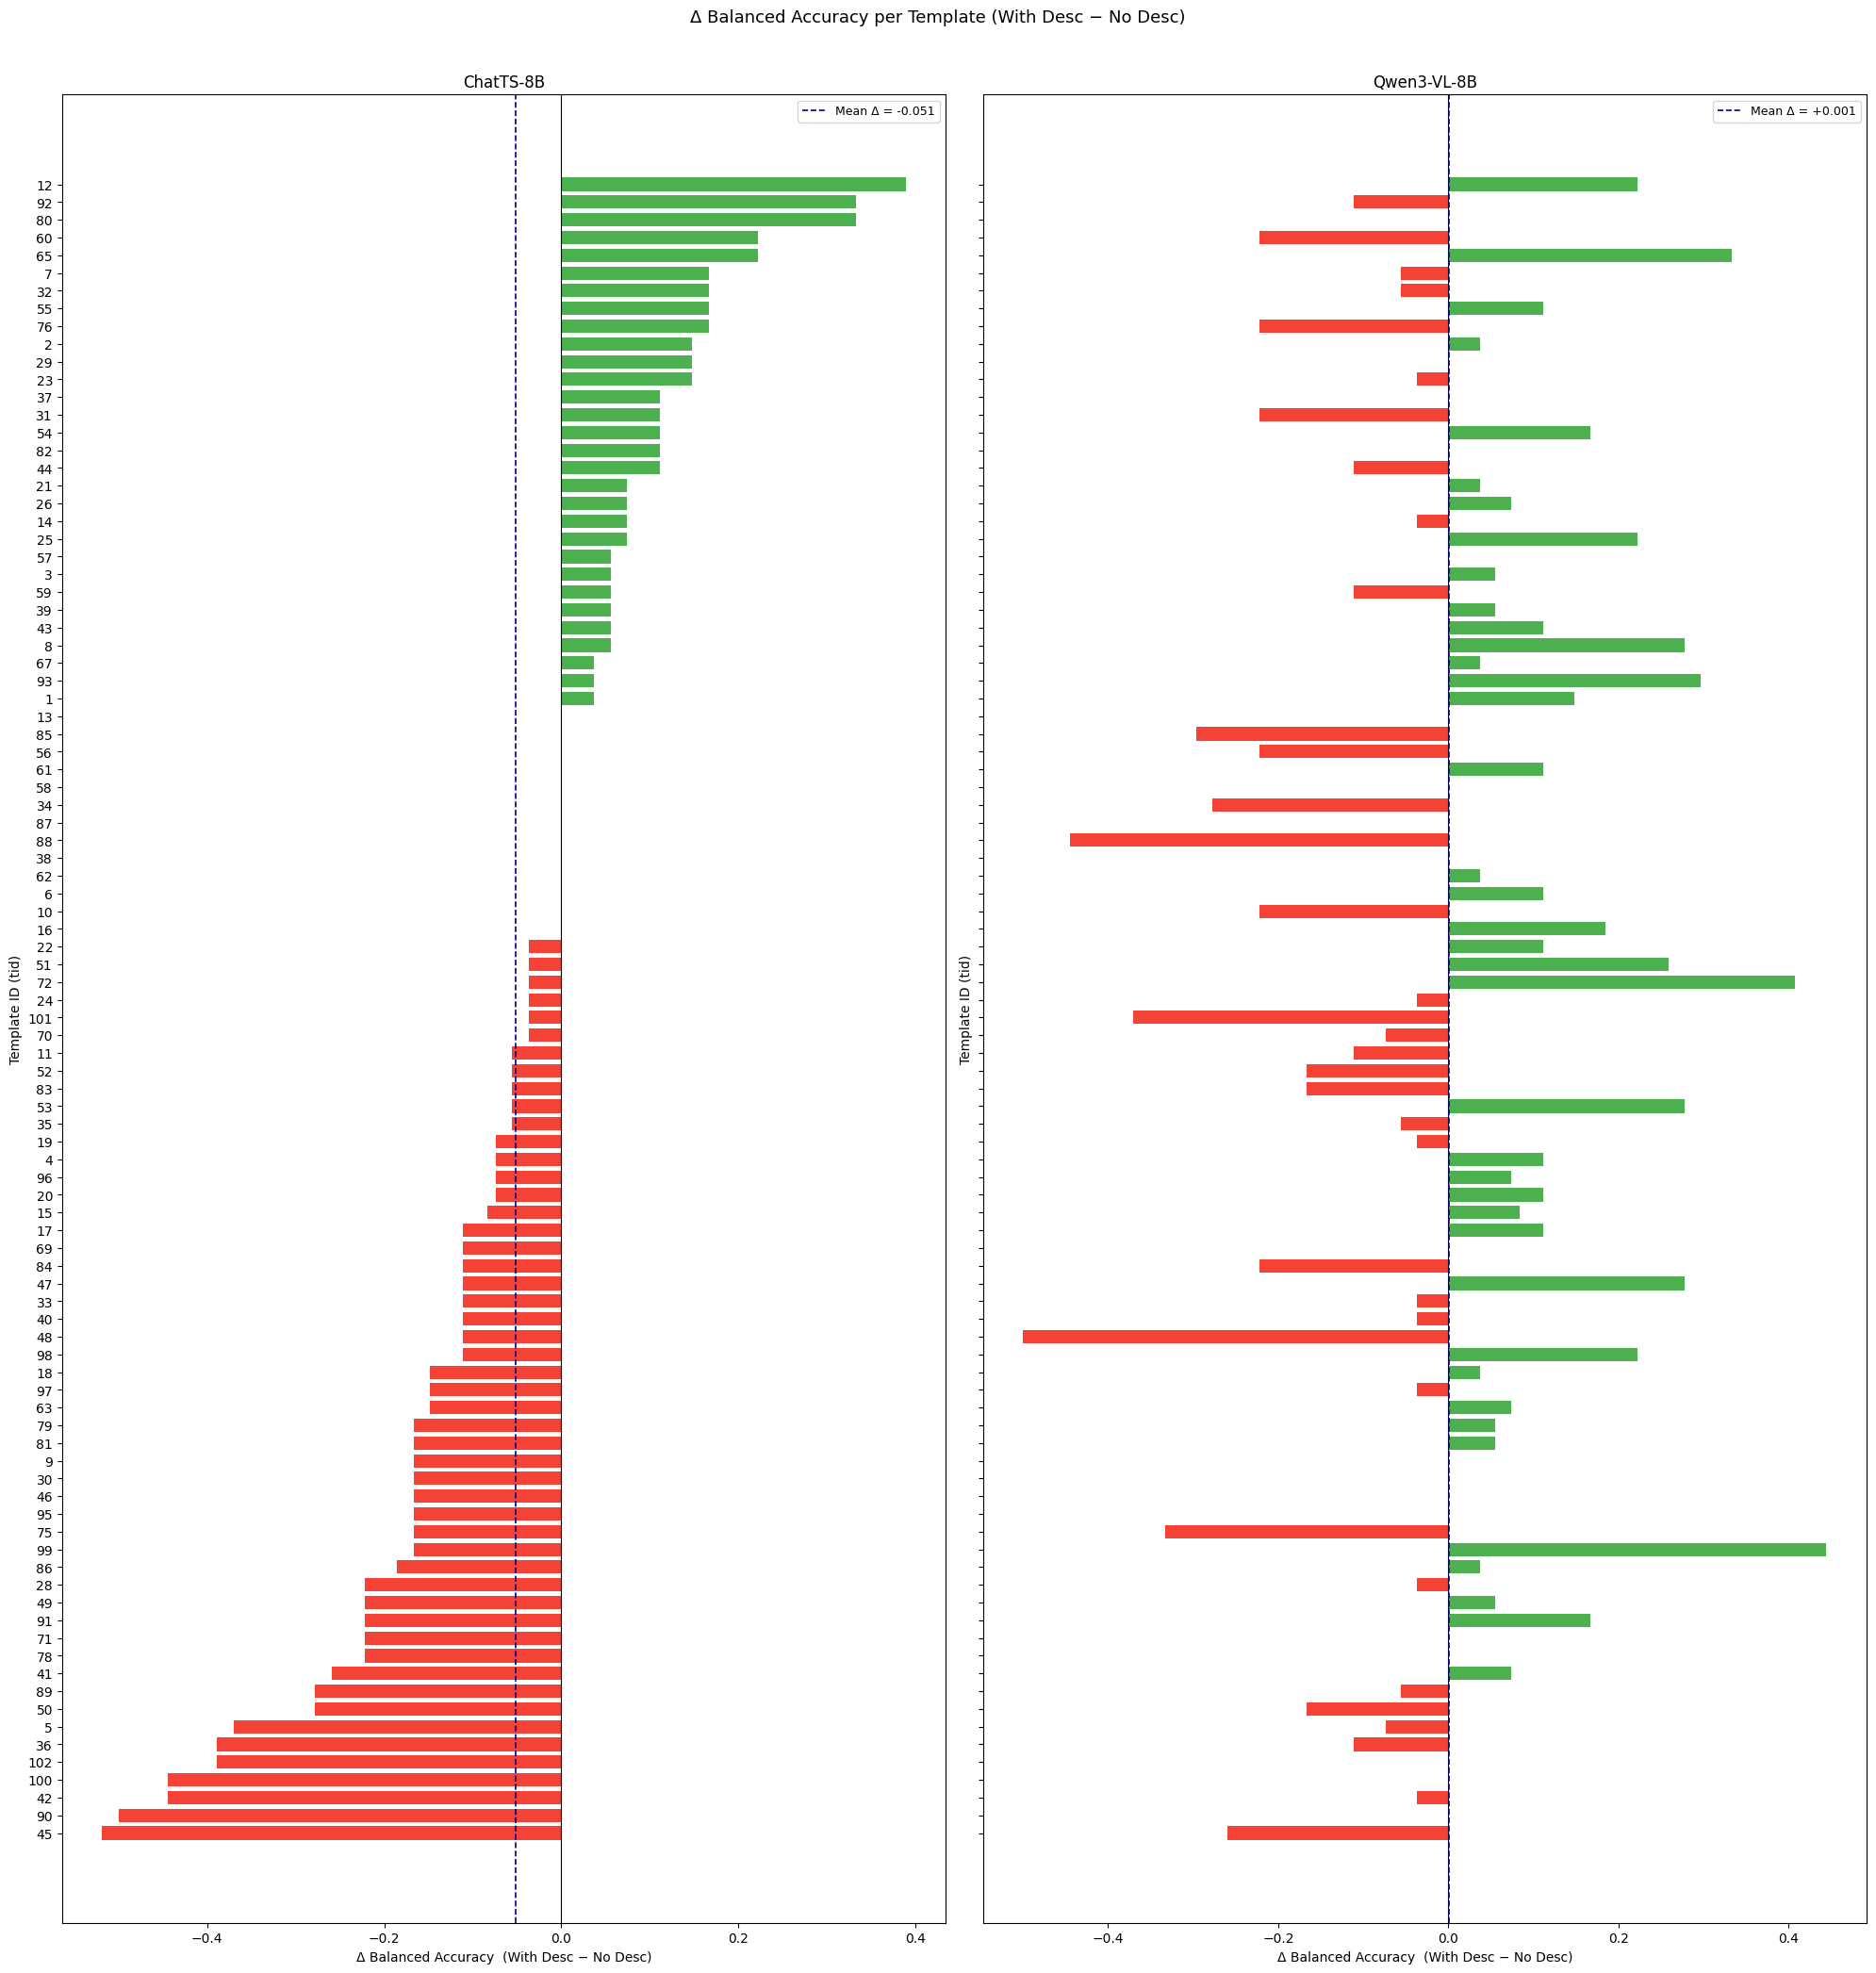

In [10]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

model_pairs = [
    (COND_CHATTS_NO, COND_CHATTS_WITH, "ChatTS-8B",   DELTA_CHATTS),
    (COND_VL_NO,     COND_VL_WITH,     "Qwen3-VL-8B", DELTA_VL),
]
available = [(a, b, lbl, dcol) for a, b, lbl, dcol in model_pairs if a in tbl.columns and b in tbl.columns]

fig, axes = plt.subplots(1, len(available),
                         figsize=(10 * len(available), max(5, len(tids) * 0.22)),
                         sharey=True)
if len(available) == 1:
    axes = [axes]

for ax, (cond_a, cond_b, model_label, dcol) in zip(axes, available):
    delta  = (tbl[cond_b] - tbl[cond_a]).dropna().sort_values(ascending=False)
    colors = ["#4CAF50" if v >= 0 else "#F44336" for v in delta]
    ax.barh(delta.index.astype(str)[::-1], delta.values[::-1], color=colors[::-1], height=0.75)
    ax.axvline(0, color="black", linewidth=0.8)
    mean_d = delta.mean()
    ax.axvline(mean_d, color="navy", linewidth=1.2, linestyle="--",
               label=f"Mean Δ = {mean_d:+.3f}")
    ax.set_xlabel("Δ Balanced Accuracy  (With Desc − No Desc)")
    ax.set_ylabel("Template ID (tid)")
    ax.set_title(model_label)
    ax.legend(fontsize=9)

    print(f"{model_label}:")
    print(f"  Mean Δ              : {mean_d:+.4f}")
    print(f"  Templates improved  : {(delta > 0).sum()} / {len(delta)}  ({(delta > 0).mean()*100:.1f}%)")
    print(f"  Templates hurt      : {(delta < 0).sum()} / {len(delta)}  ({(delta < 0).mean()*100:.1f}%)")
    print(f"  Templates tied      : {(delta == 0).sum()} / {len(delta)}")
    print()

plt.suptitle("Δ Balanced Accuracy per Template (With Desc − No Desc)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Scatter: No Description vs With Description

Points **above** the diagonal → description helps. Points **below** → description hurts.

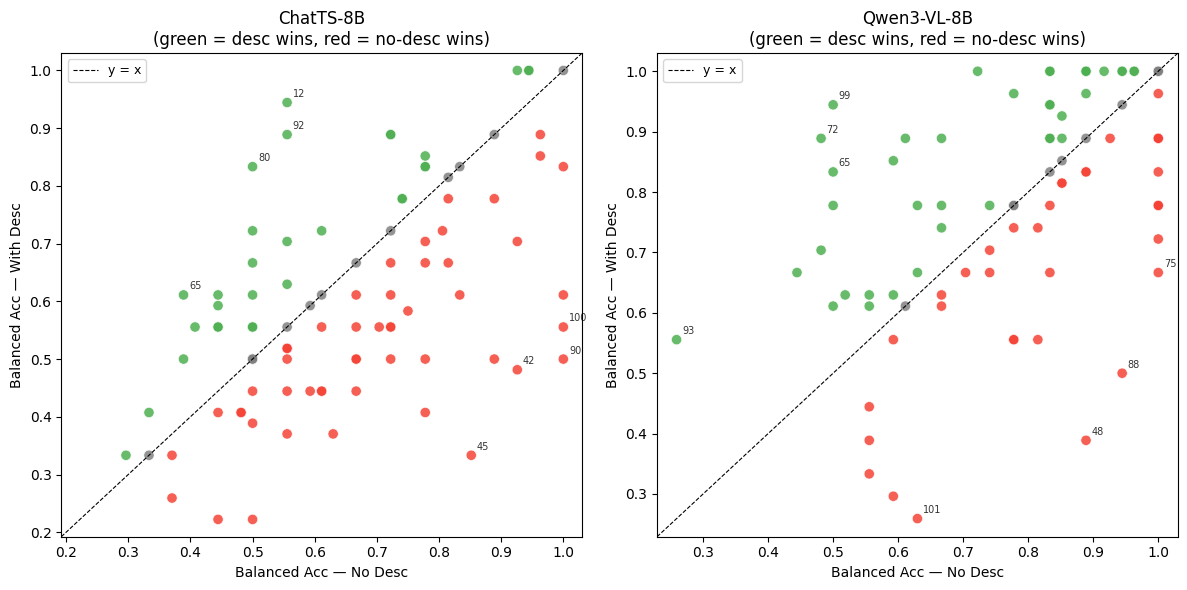

In [11]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 6))
if len(available) == 1:
    axes = [axes]

for ax, (cond_a, cond_b, model_label, _) in zip(axes, available):
    paired = tbl[[cond_a, cond_b]].dropna()
    x, y   = paired[cond_a].values, paired[cond_b].values
    colors = ["#4CAF50" if yi > xi else "#F44336" if yi < xi else "gray"
              for xi, yi in zip(x, y)]
    ax.scatter(x, y, c=colors, s=55, alpha=0.85, edgecolors="white", linewidths=0.5)
    lim = [min(x.min(), y.min()) - 0.03, max(x.max(), y.max()) + 0.03]
    ax.plot(lim, lim, "k--", linewidth=0.8, label="y = x")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Balanced Acc — No Desc")
    ax.set_ylabel("Balanced Acc — With Desc")
    ax.set_title(f"{model_label}\n(green = desc wins, red = no-desc wins)")
    ax.legend(fontsize=9)
    delta_arr = y - x
    for i in list(np.argsort(delta_arr)[-4:][::-1]) + list(np.argsort(delta_arr)[:4]):
        ax.annotate(str(paired.index[i]), (x[i], y[i]), fontsize=7, alpha=0.8,
                    xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.show()

### Wilcoxon Signed-Rank Test

Paired test per model: is **With Description** significantly different from **No Description**?

In [12]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

def sig(p):
    return "*** (p<0.001)" if p < 0.001 else "** (p<0.01)" if p < 0.01 else "* (p<0.05)" if p < 0.05 else "n.s."

model_pairs_wilcox = [
    (COND_CHATTS_NO, COND_CHATTS_WITH, "ChatTS-8B"),
    (COND_VL_NO,     COND_VL_WITH,     "Qwen3-VL-8B"),
]

for cond_a, cond_b, model_label in model_pairs_wilcox:
    if cond_a not in tbl.columns or cond_b not in tbl.columns:
        print(f"{model_label}: data not available\n"); continue
    paired = tbl[[cond_a, cond_b]].dropna()
    a_vals, b_vals = paired[cond_a].values, paired[cond_b].values
    delta_vals = b_vals - a_vals

    stat_2, p_2 = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="two-sided")
    stat_g, p_g = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="greater")
    stat_l, p_l = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="less")

    print(f"{'─'*55}")
    print(f"{model_label}")
    print(f"  Paired templates      : {len(paired)}")
    print(f"  Mean (No Desc)        : {a_vals.mean():.4f}")
    print(f"  Mean (With Desc)      : {b_vals.mean():.4f}")
    print(f"  Mean Δ (with − no)    : {delta_vals.mean():+.4f}")
    print(f"  Templates improved    : {(delta_vals > 0).sum()} / {len(delta_vals)}  ({(delta_vals > 0).mean()*100:.1f}%)")
    print(f"  Templates hurt        : {(delta_vals < 0).sum()} / {len(delta_vals)}  ({(delta_vals < 0).mean()*100:.1f}%)")
    print(f"  Wilcoxon two-sided    : stat={stat_2:.1f},  p={p_2:.4f}  {sig(p_2)}")
    print(f"  Wilcoxon (with>no)    : stat={stat_g:.1f},  p={p_g:.4f}  {sig(p_g)}")
    print(f"  Wilcoxon (with<no)    : stat={stat_l:.1f},  p={p_l:.4f}  {sig(p_l)}")
    print()

───────────────────────────────────────────────────────
ChatTS-8B
  Paired templates      : 94
  Mean (No Desc)        : 0.6562
  Mean (With Desc)      : 0.6051
  Mean Δ (with − no)    : -0.0511
  Templates improved    : 30 / 94  (31.9%)
  Templates hurt        : 51 / 94  (54.3%)
  Wilcoxon two-sided    : stat=1470.5,  p=0.0068  ** (p<0.01)
  Wilcoxon (with>no)    : stat=1470.5,  p=0.9966  n.s.
  Wilcoxon (with<no)    : stat=1470.5,  p=0.0034  ** (p<0.01)

───────────────────────────────────────────────────────
Qwen3-VL-8B
  Paired templates      : 94
  Mean (No Desc)        : 0.7970
  Mean (With Desc)      : 0.7981
  Mean Δ (with − no)    : +0.0011
  Templates improved    : 39 / 94  (41.5%)
  Templates hurt        : 36 / 94  (38.3%)
  Wilcoxon two-sided    : stat=2052.0,  p=0.7460  n.s.
  Wilcoxon (with>no)    : stat=2223.0,  p=0.3730  n.s.
  Wilcoxon (with<no)    : stat=2223.0,  p=0.6270  n.s.



### Cross-Model Pairwise Comparison

In [13]:
tbl   = mean_p.drop(index="Macro Avg", errors="ignore")
pairs = [
    (COND_CHATTS_NO,   COND_VL_NO,       "ChatTS No Desc vs QwenVL No Desc"),
    (COND_CHATTS_WITH, COND_VL_WITH,     "ChatTS With Desc vs QwenVL With Desc"),
    (COND_CHATTS_NO,   COND_CHATTS_WITH, "ChatTS: No Desc vs With Desc"),
    (COND_VL_NO,       COND_VL_WITH,     "QwenVL: No Desc vs With Desc"),
]

print("Pairwise Wilcoxon signed-rank tests (two-sided, no correction):")
print(f"{'─'*65}")
rows = []
for cond_a, cond_b, label in pairs:
    if cond_a not in tbl.columns or cond_b not in tbl.columns:
        continue
    paired = tbl[[cond_a, cond_b]].dropna()
    a_vals, b_vals = paired[cond_a].values, paired[cond_b].values
    delta_mean = (b_vals - a_vals).mean()
    try:
        stat, p = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="two-sided")
    except ValueError:
        stat, p = np.nan, np.nan
    rows.append({"Comparison": label, "N": len(paired),
                 f"Mean(A)": a_vals.mean(), f"Mean(B)": b_vals.mean(),
                 "Mean Δ (B−A)": delta_mean, "stat": stat, "p-value": p,
                 "Sig.": sig(p)})

df_pairs = pd.DataFrame(rows)
display(
    df_pairs.style
    .format({"Mean(A)": "{:.4f}", "Mean(B)": "{:.4f}",
             "Mean Δ (B−A)": "{:+.4f}", "stat": "{:.1f}", "p-value": "{:.4f}"})
    .background_gradient(cmap="RdBu", subset=["Mean Δ (B−A)"], axis=0)
    .set_caption("Pairwise Wilcoxon (two-sided) between conditions")
)

Pairwise Wilcoxon signed-rank tests (two-sided, no correction):
─────────────────────────────────────────────────────────────────


,Comparison,N,Mean(A),Mean(B),Mean Δ (B−A),stat,p-value,Sig.
0,ChatTS No Desc vs QwenVL No Desc,94,0.6562,0.7970,+0.1408,588.0,0.0000,*** (p<0.001)
1,ChatTS With Desc vs QwenVL With Desc,94,0.6051,0.7981,+0.1930,385.5,0.0000,*** (p<0.001)
2,ChatTS: No Desc vs With Desc,94,0.6562,0.6051,-0.0511,1470.5,0.0068,** (p<0.01)
3,QwenVL: No Desc vs With Desc,94,0.7970,0.7981,+0.0011,2052.0,0.7460,n.s.


## 5 · Results by TSE Difficulty and Category

,N Templates,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc,Δ ChatTS (with−no),Δ QwenVL (with−no)
Difficulty,,,,,,,
easy,32,0.647,0.596,0.777,0.791,-0.051,+0.013
hard,59,0.656,0.594,0.809,0.800,-0.062,-0.009
medium,3,0.765,0.920,0.765,0.840,+0.154,+0.074


,N Templates,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc,Δ ChatTS (with−no),Δ QwenVL (with−no)
Category,,,,,,,
Anolmaly Detection,9,0.718,0.685,0.817,0.842,-0.033,+0.025
Causality Analysis,7,0.664,0.468,0.690,0.738,-0.196,+0.048
Noise Understanding,13,0.631,0.645,0.812,0.818,+0.014,+0.006
Pattern Recognition,48,0.671,0.628,0.798,0.801,-0.043,+0.003
Similarity Analysis,17,0.599,0.525,0.816,0.776,-0.074,-0.040


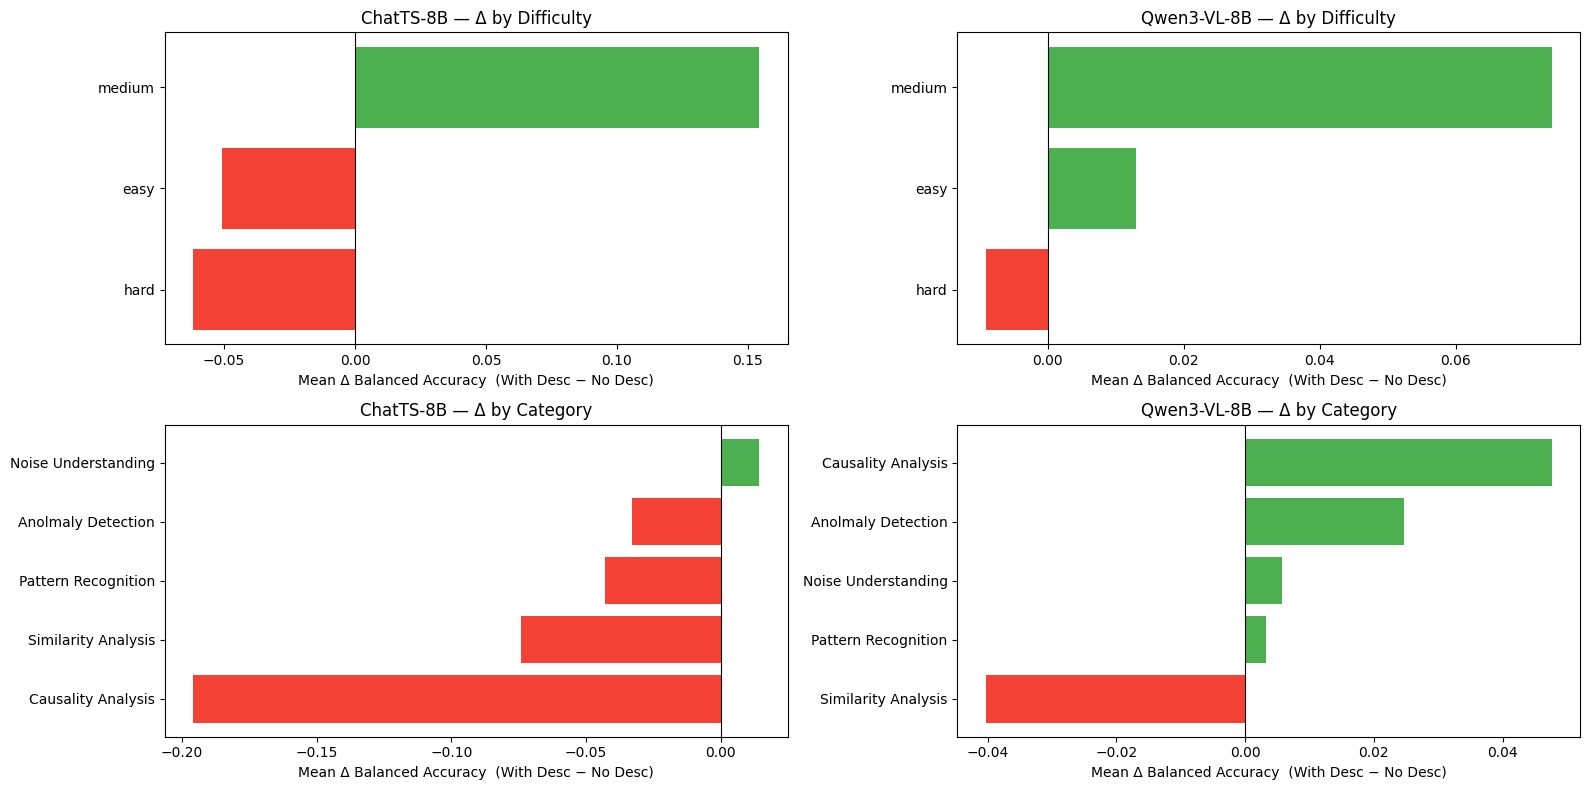

In [14]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore").copy()
# Re-attach metadata (may have been dropped in some reindex steps)
tbl["Difficulty"] = pd.Series({t: tid_meta.get(t, {}).get("difficulty", "?") for t in tbl.index})
tbl["Category"]   = pd.Series({t: tid_meta.get(t, {}).get("category",   "?") for t in tbl.index})

cat_cols = cols + DELTA_COLS

for group_by, group_label in [("Difficulty", "Difficulty"), ("Category", "Category")]:
    grp_summary = tbl.groupby(group_by)[cat_cols].mean()
    grp_counts  = tbl.groupby(group_by).size().rename("N Templates")
    grp_summary = pd.concat([grp_counts, grp_summary], axis=1)

    vabs = grp_summary[DELTA_COLS].abs().max().max() if DELTA_COLS else 0.1
    display(
        grp_summary.style
        .format({"N Templates": "{:.0f}",
                 **{c: "{:.3f}" for c in cols},
                 **{c: "{:+.3f}" for c in DELTA_COLS}})
        .background_gradient(cmap="RdYlGn", axis=None, subset=cols, vmin=0, vmax=1)
        .background_gradient(cmap="RdBu",   axis=None, subset=DELTA_COLS, vmin=-vabs, vmax=vabs)
        .set_caption(f"Mean Balanced Accuracy & Δ by {group_label}")
    )

# Bar charts: Δ by difficulty and category
fig, axes = plt.subplots(2, len(available) if available else 1,
                         figsize=(8 * max(len(available), 1), 8))
if len(available) == 1:
    axes = axes.reshape(2, 1)

for col_i, (_, _, model_label, dcol) in enumerate(available):
    for row_i, (group_by, group_label) in enumerate([("Difficulty", "Difficulty"), ("Category", "Category")]):
        ax = axes[row_i][col_i]
        grp_delta = tbl.groupby(group_by)[dcol].mean().sort_values()
        bar_c = ["#4CAF50" if v >= 0 else "#F44336" for v in grp_delta]
        ax.barh(grp_delta.index, grp_delta.values, color=bar_c)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Mean Δ Balanced Accuracy  (With Desc − No Desc)")
        ax.set_title(f"{model_label} — Δ by {group_label}")

plt.tight_layout()
plt.show()

### Overall Accuracy Table by Difficulty and Category

Treats all templates within each group as one pooled task (weighted by test size).

In [15]:
for group_col, group_label in [("difficulty", "Difficulty"), ("category", "Category")]:
    rows = []
    groups = finished[group_col].dropna().unique()
    for grp in sorted(groups):
        grp_df = finished[finished[group_col] == grp]
        row = {group_label: grp, "N Templates": grp_df["tid"].nunique()}
        for cond in CONDITIONS:
            cdf = grp_df[grp_df["condition"] == cond]
            if cdf.empty:
                row[cond] = np.nan
                continue
            per_tid = cdf.groupby("tid").agg(
                bal_acc=("balanced_accuracy", "mean"),
                test_size=("total_test_size", "mean"),
            ).dropna(subset=["bal_acc"])
            weights = per_tid["test_size"].fillna(1)
            row[cond] = np.average(per_tid["bal_acc"], weights=weights)
        rows.append(row)

    grp_overall = pd.DataFrame(rows).set_index(group_label)
    vabs_delta = 0.1  # no delta cols here, just for consistency
    display(
        grp_overall.style
        .format({"N Templates": "{:.0f}", **{c: "{:.4f}" for c in CONDITIONS if c in grp_overall.columns}})
        .background_gradient(cmap="RdYlGn", axis=None,
                             subset=[c for c in CONDITIONS if c in grp_overall.columns],
                             vmin=0, vmax=1)
        .set_caption(f"Overall Weighted Accuracy by {group_label} (weighted by test size)")
    )

,N Templates,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc
Difficulty,,,,,
easy,32,0.6467,0.5883,0.7678,0.7906
hard,59,0.6544,0.5893,0.7985,0.7931
medium,3,0.7917,0.9167,0.7778,0.8333


,N Templates,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc
Category,,,,,
Anolmaly Detection,9,0.7315,0.6852,0.8148,0.8519
Causality Analysis,7,0.6235,0.4506,0.6667,0.6975
Noise Understanding,13,0.6349,0.6468,0.7976,0.8135
Pattern Recognition,48,0.6738,0.6219,0.7948,0.8020
Similarity Analysis,17,0.5826,0.5105,0.7958,0.7598


## 6 · Critical Difference Diagram

All 4 conditions ranked via **Friedman test** followed by **pairwise Wilcoxon signed-rank
with Holm–Bonferroni correction** at α = 0.05.

Conditions connected by a horizontal bar are **not significantly different**.  
Lower average rank = better (rank 1 is best per template).

In [16]:
tbl       = mean_p.drop(index="Macro Avg", errors="ignore")
stat_cols = [c for c in cols if c in tbl.columns]
pivot_stat = tbl[stat_cols].dropna()

print(f"Templates used for CD diagram: {len(pivot_stat)}")
print(f"  (dropped {len(tbl) - len(pivot_stat)} templates with any missing condition)")

groups = [pivot_stat[c].values for c in stat_cols]
friedman_stat, friedman_p = friedmanchisquare(*groups)
print(f"\nFriedman test:")
print(f"  χ² = {friedman_stat:.4f},  p = {friedman_p:.6f}  {sig(friedman_p)}")

Templates used for CD diagram: 94
  (dropped 0 templates with any missing condition)

Friedman test:
  χ² = 73.3081,  p = 0.000000  *** (p<0.001)


Average ranks (1 = best):
  QwenVL · With Desc            : 1.9574
  QwenVL · No Desc              : 1.9734
  ChatTS · No Desc              : 2.8830
  ChatTS · With Desc            : 3.1862

Pairwise Wilcoxon + Holm–Bonferroni (α=0.05):
  [✓ sig.]  ChatTS · With Desc  vs  QwenVL · With Desc  — p=0.0000
  [✓ sig.]  ChatTS · With Desc  vs  QwenVL · No Desc  — p=0.0000
  [✓ sig.]  ChatTS · No Desc  vs  QwenVL · No Desc  — p=0.0000
  [✓ sig.]  ChatTS · No Desc  vs  QwenVL · With Desc  — p=0.0000
  [✓ sig.]  ChatTS · No Desc  vs  ChatTS · With Desc  — p=0.0068
  [✗ n.s.]  QwenVL · No Desc  vs  QwenVL · With Desc  — p=0.7460


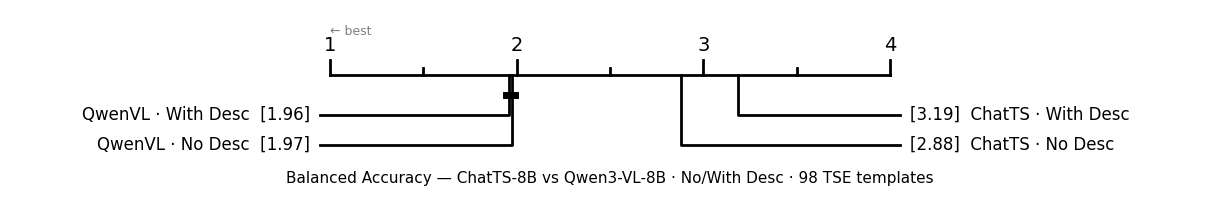

In [17]:
def graph_ranks(avranks, names, p_values, lowv=None, highv=None,
                width=9, textspace=2.5, labels=False):
    width, textspace = float(width), float(textspace)
    sums, nnames = avranks, names
    if lowv is None:
        lowv = min(1, int(math.floor(min(sums))))
    if highv is None:
        highv = max(len(avranks), int(math.ceil(max(sums))))
    cline = 0.65
    k = len(sums)
    scalewidth = width - 2 * textspace

    def rankpos(rank):
        return textspace + scalewidth / (highv - lowv) * (rank - lowv)

    minnotsig = 2 * 0.2
    height = cline + ((k + 1) / 2) * 0.3 + minnotsig
    fig = plt.figure(figsize=(width, height))
    fig.set_facecolor("white")
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    hf, wf = 1.0 / height, 1.0 / width
    ax.plot([0, 1], [0, 1], c="w")
    ax.set_xlim(0, 1); ax.set_ylim(1, 0)

    def line(pts, color="k", **kw):
        ax.plot([wf * p[0] for p in pts], [hf * p[1] for p in pts], color=color, **kw)

    def text(x, y, s, **kw):
        ax.text(wf * x, hf * y, s, **kw)

    line([(textspace, cline), (width - textspace, cline)], linewidth=2)
    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = 0.15 if a != int(a) else 0.3
        line([(rankpos(a), cline - tick / 2), (rankpos(a), cline)], linewidth=2)
    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.05, str(a),
             ha="center", va="bottom", size=14)
    text(textspace, cline - tick / 2 - 0.22, "← best",
         ha="left", va="bottom", size=9, color="gray")

    space = 0.3
    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsig + i * space
        line([(rankpos(sums[i]), cline), (rankpos(sums[i]), chei),
              (textspace - 0.1, chei)], linewidth=2)
        label = f"{nnames[i]}  [{sums[i]:.2f}]" if labels else nnames[i]
        text(textspace - 0.2, chei, label, ha="right", va="center", size=12)

    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsig + (k - i - 1) * space
        line([(rankpos(sums[i]), cline), (rankpos(sums[i]), chei),
              (textspace + scalewidth + 0.1, chei)], linewidth=2)
        label = f"[{sums[i]:.2f}]  {nnames[i]}" if labels else nnames[i]
        text(textspace + scalewidth + 0.2, chei, label, ha="left", va="center", size=12)

    m = len(nnames)
    g_data = np.zeros((m, m), dtype=np.int64)
    for p in p_values:
        if not p[3]:
            i = list(nnames).index(p[0])
            j = list(nnames).index(p[1])
            g_data[min(i, j), max(i, j)] = 1
    start = cline + 0.2
    for clq in networkx.find_cliques(networkx.Graph(g_data)):
        if len(clq) == 1:
            continue
        r_lo = rankpos(sums[min(clq)])
        r_hi = rankpos(sums[max(clq)])
        line([(r_lo - 0.03, start), (r_hi + 0.03, start)], linewidth=5)
        start += 0.12
    return fig


def draw_cd_diagram(df_perf, alpha=0.05, title=None, labels=True):
    classifiers = df_perf["classifier_name"].unique().tolist()

    p_values = []
    for i in range(len(classifiers) - 1):
        for j in range(i + 1, len(classifiers)):
            c1, c2 = classifiers[i], classifiers[j]
            d1 = df_perf[df_perf["classifier_name"] == c1].set_index("dataset_name")["accuracy"]
            d2 = df_perf[df_perf["classifier_name"] == c2].set_index("dataset_name")["accuracy"]
            common = d1.index.intersection(d2.index)
            if len(common) < 2:
                continue
            try:
                p = wilcoxon(d1[common].values, d2[common].values, zero_method="pratt")[1]
            except ValueError:
                p = 1.0
            p_values.append([c1, c2, p, False])

    p_values.sort(key=lambda x: x[2])
    m_pairs = len(p_values)
    for i, pv in enumerate(p_values):
        pv[3] = pv[2] <= alpha / (m_pairs - i)

    pivot = df_perf.pivot(index="dataset_name", columns="classifier_name", values="accuracy")
    avg_ranks = pivot.rank(axis=1, ascending=False).mean(axis=0).sort_values(ascending=True)

    print("Average ranks (1 = best):")
    for name, rank in avg_ranks.items():
        print(f"  {name:30s}: {rank:.4f}")

    print(f"\nPairwise Wilcoxon + Holm–Bonferroni (α={alpha}):")
    for pv in p_values:
        marker = "✓ sig." if pv[3] else "✗ n.s."
        print(f"  [{marker}]  {pv[0]}  vs  {pv[1]}  — p={pv[2]:.4f}")

    fig = graph_ranks(
        avg_ranks.values,
        avg_ranks.index.values,
        [tuple(p) for p in p_values],
        width=12, textspace=3.2, labels=labels
    )
    if title:
        fig.text(0.5, 0.02, title, ha="center", va="bottom", fontsize=11)
    plt.show()


df_perf = (
    pivot_stat.reset_index()
    .melt(id_vars="tid", var_name="classifier_name", value_name="accuracy")
    .rename(columns={"tid": "dataset_name"})
)
df_perf["dataset_name"] = df_perf["dataset_name"].astype(str)

draw_cd_diagram(
    df_perf=df_perf,
    alpha=0.05,
    title="Balanced Accuracy — ChatTS-8B vs Qwen3-VL-8B · No/With Desc · 98 TSE templates",
    labels=True
)

## 7 · Summary

In [18]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

print("=" * 60)
print(f"Experiment  : {EXP_ID}")
print(f"Models      : ChatTS-8B  |  Qwen3-VL-8B")
print(f"Templates   : {len(tbl)} / 98")
print(f"Seeds       : {N_SEEDS}  (0, 3, 6)")
print("=" * 60)

print("\nOverall Accuracy (macro avg across all templates):")
for c in cols:
    print(f"  {c:30s}: {mean_p.loc['Macro Avg', c]:.4f}")

print("\nOverall Accuracy (weighted avg by test size):")
for c in cols:
    cdf = finished[finished["condition"] == c]
    per_tid = cdf.groupby("tid").agg(
        bal_acc=("balanced_accuracy", "mean"),
        test_size=("total_test_size", "mean"),
    ).dropna(subset=["bal_acc"])
    w = per_tid["test_size"].fillna(1)
    print(f"  {c:30s}: {np.average(per_tid['bal_acc'], weights=w):.4f}")

print("\nDescription effect summary:")
for cond_a, cond_b, model_label, dcol in [
        (COND_CHATTS_NO, COND_CHATTS_WITH, "ChatTS-8B",   DELTA_CHATTS),
        (COND_VL_NO,     COND_VL_WITH,     "QwenVL-8B",   DELTA_VL)]:
    if dcol not in tbl.columns:
        continue
    delta = tbl[dcol].dropna()
    print(f"\n  {model_label}:")
    print(f"    Mean Δ              : {delta.mean():+.4f}")
    print(f"    Templates improved  : {(delta > 0).sum()} / {len(delta)}  ({(delta > 0).mean()*100:.1f}%)")
    print(f"    Templates hurt      : {(delta < 0).sum()} / {len(delta)}  ({(delta < 0).mean()*100:.1f}%)")

print("\nTop 5 templates where description helps most (either model):")
best_delta = tbl[DELTA_COLS].max(axis=1).nlargest(5)
for tid_val, val in best_delta.items():
    row = tbl.loc[tid_val, DELTA_COLS]
    q = tid_meta.get(tid_val, {}).get("question", "")[:50]
    print(f"  tid={tid_val:3d}  ChatTS {row[DELTA_CHATTS]:+.3f}  |  QwenVL {row[DELTA_VL]:+.3f}  — {q}")

print("\nTop 5 templates where description hurts most (either model):")
worst_delta = tbl[DELTA_COLS].min(axis=1).nsmallest(5)
for tid_val, val in worst_delta.items():
    row = tbl.loc[tid_val, DELTA_COLS]
    q = tid_meta.get(tid_val, {}).get("question", "")[:50]
    print(f"  tid={tid_val:3d}  ChatTS {row[DELTA_CHATTS]:+.3f}  |  QwenVL {row[DELTA_VL]:+.3f}  — {q}")

Experiment  : tse_desc_ablation_full
Models      : ChatTS-8B  |  Qwen3-VL-8B
Templates   : 94 / 98
Seeds       : 3  (0, 3, 6)

Overall Accuracy (macro avg across all templates):
  ChatTS · No Desc              : 0.6562
  ChatTS · With Desc            : 0.6051
  QwenVL · No Desc              : 0.7970
  QwenVL · With Desc            : 0.7981

Overall Accuracy (weighted avg by test size):
  ChatTS · No Desc              : 0.6566
  ChatTS · With Desc            : 0.6003
  QwenVL · No Desc              : 0.7874
  QwenVL · With Desc            : 0.7937

Description effect summary:

  ChatTS-8B:
    Mean Δ              : -0.0511
    Templates improved  : 30 / 94  (31.9%)
    Templates hurt      : 51 / 94  (54.3%)

  QwenVL-8B:
    Mean Δ              : +0.0011
    Templates improved  : 39 / 94  (41.5%)
    Templates hurt      : 36 / 94  (38.3%)

Top 5 templates where description helps most (either model):
  tid= 99  ChatTS -0.167  |  QwenVL +0.444  — Is the two time series lagged version of e